In [22]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [23]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cpu


### Loading the SAM 2 video predictor

In [24]:
import os
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "../../sam2/checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device='cpu')
# with image encoder compiled
# predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device,vos_optimized=True)


configs/sam2.1/sam2.1_hiera_b+.yaml


In [25]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

#### Select an example video

We assume that the video is stored as a list of JPEG frames with filenames like `<frame_index>.jpg`.

For your custom videos, you can extract their JPEG frames using ffmpeg (https://ffmpeg.org/) as follows:
```
ffmpeg -i <your_video>.mp4 -q:v 2 -start_number 0 <output_dir>/'%05d.jpg'
```
where `-q:v` generates high-quality JPEG frames and `-start_number 0` asks ffmpeg to start the JPEG file from `00000.jpg`.

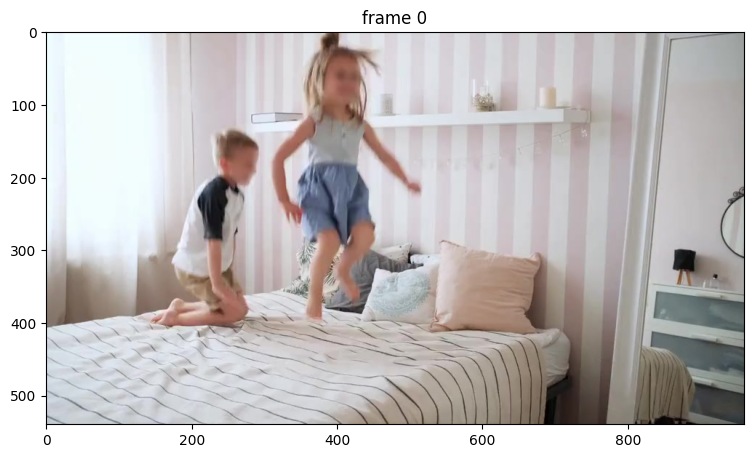

In [26]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
# video_dir = "notebooks/videos/bedroom.mp4"
# video_dir = "notebooks/videos/test.mp4"
video_dir = "videos/bedroom"
# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# # take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

#### Initialize the inference state

SAM 2 requires stateful inference for interactive video segmentation, so we need to initialize an **inference state** on this video.

During initialization, it loads all the JPEG frames in `video_path` and stores their pixels in `inference_state` (as shown in the progress bar below).

In [27]:
# import torch._dynamo
# torch._dynamo.config.suppress_errors = True
# os.environ["TORCH_LOGS"] = "+dynamo"
# os.environ["TORCHDYNAMO_VERBOSE"] = "1"
# predictor.reset_state(inference_state)
from rds import RedisAccess
rds = RedisAccess(0)
model_id = "sam2.1_hiera_base_plus"
video_dir_for_init = "./videos/bedroom01"

inference_state = predictor.init_state(video_path=video_dir_for_init)
img_list = [{"md5": os.path.splitext(p)[0]} for idx,p in enumerate(frame_names)]
inference_state['rds'] = rds
inference_state['img_list'] = img_list
inference_state['model_id'] = model_id
inference_state["num_frames"] = 200

frame loading (JPEG): 100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 42.67it/s]


/home/a70495/sam2_dev/sam2/sam2_video_predictor.py:813: UserWarning: cannot import name '_C' from 'sam2' (/home/a70495/sam2_dev/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  # potentially fill holes in the predicted masks


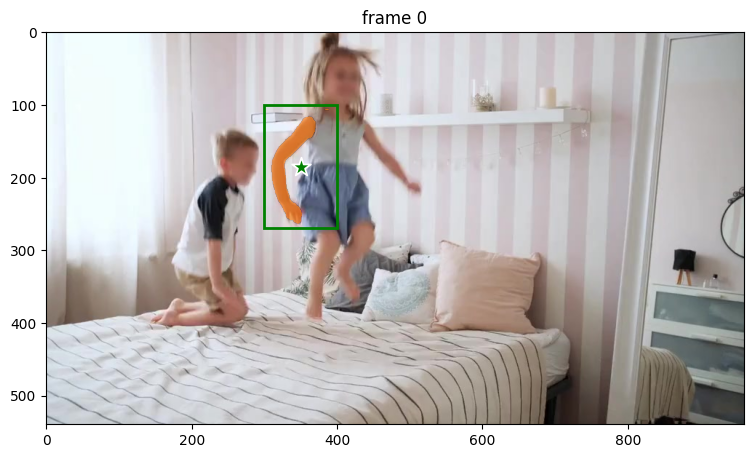

In [28]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

# Let's add a positive click at (x, y) = (210, 350) to get started
points = np.array([[210, 350]], dtype=np.float32)
# box = np.array([550, 480, 750, 600], dtype=np.float32)
# kids hand
box = np.array([300, 100, 400, 270], dtype=np.float32)
# box = np.array([400, 350, 800, 600], dtype=np.float32)

# for labels, `1` means positive click and `0` means negative click
labels = np.array([1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    # points=points,
    # labels=labels,
    box=box
)


# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
# show_points(points, labels, plt.gca())
show_box(box, plt.gca())
points = np.array([[(box[0]+box[2])/2,(box[1]+box[3])/2]], dtype=np.float32)
show_points(points, labels, plt.gca())

show_mask((out_mask_logits[inference_state['obj_id_to_idx'][ann_obj_id]] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[inference_state['obj_id_to_idx'][ann_obj_id]])

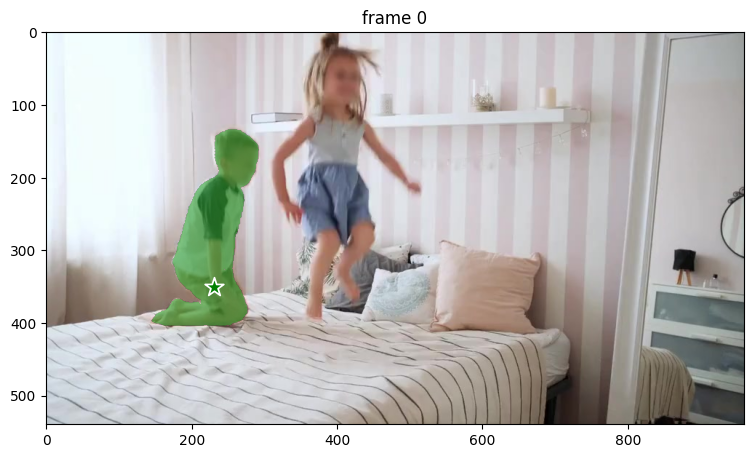

In [29]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 2  # give a unique id to each object we interact with (it can be any integers)

# # Let's add a positive click at (x, y) = (210, 350) to get started
points = np.array([[230, 350]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,

)


# # show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())

show_mask((out_mask_logits[inference_state['obj_id_to_idx'][ann_obj_id]] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[inference_state['obj_id_to_idx'][ann_obj_id]])

#### Step 3: Propagate the prompts to get the masklet across the video

propagate in video: 100%|████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:21<00:00,  1.02s/it]


time: 22.09s


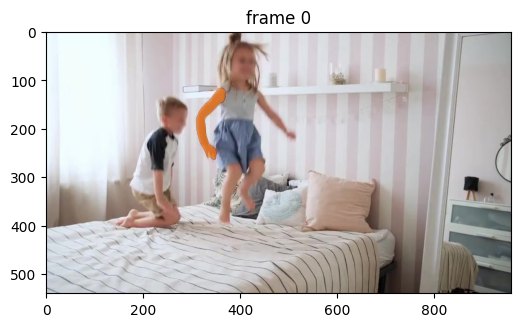

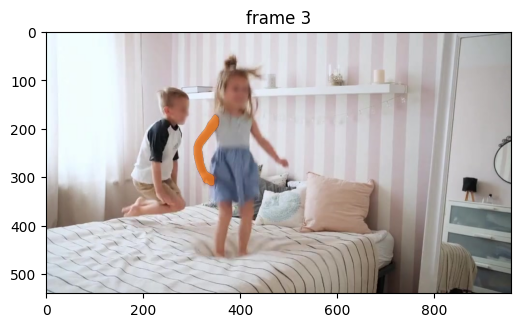

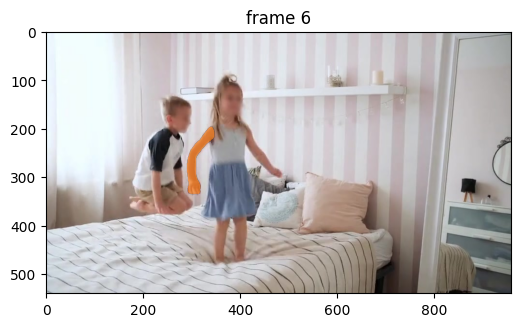

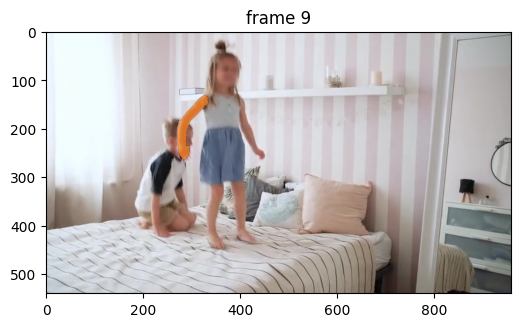

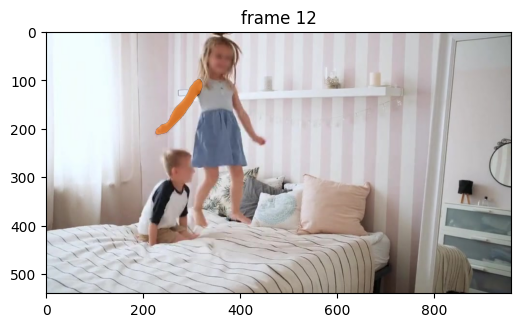

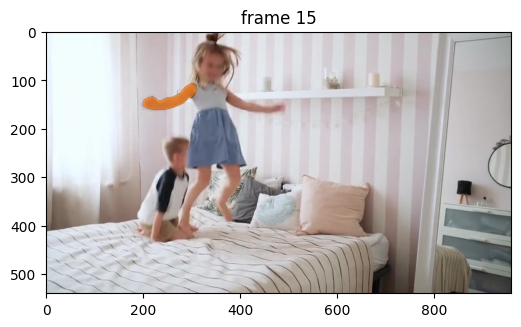

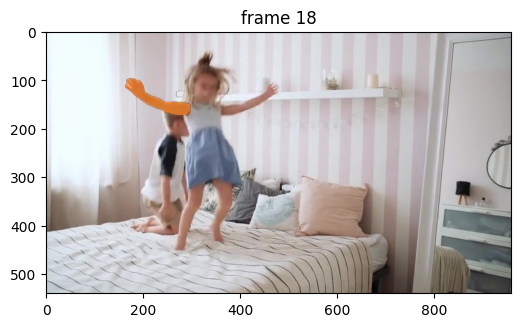

In [30]:
import time
start = time.time()
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
start_frame_idx = 0
max_frame_num_to_track = 20
track_obj_list = [1]
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state,start_frame_idx=start_frame_idx,
                             max_frame_num_to_track=max_frame_num_to_track,track_obj_list=track_obj_list):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }
    # break
print(f'time: {time.time() - start:.2f}s')
# # render the segmentation results every few frames
vis_frame_stride = 3
plt.close("all")
for out_frame_idx in range(start_frame_idx, start_frame_idx + max_frame_num_to_track, vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [ ]:
from pympler import asizeof

for key in inference_state.keys():
    print(f"{key}: {asizeof.asizeof(inference_state[key]) / 1024:.2f} KB")
    
print(f'total: {sum(asizeof.asizeof(inference_state[key]) for key in inference_state.keys()) / 1024:.2f} KB')

In [ ]:
from pympler import asizeof
# z = [1, 2, 3, 4, 5]
print(f"完整記憶體大小: {asizeof.asizeof( inference_state ) / 1024 :.2f} KB")
# print(f"z 的完整記憶體大小: {asizeof.asizeof(inference_state['output_dict_per_obj'][0]['non_cond_frame_outputs'])} bytes")
# inference_state["images"]=None

In [ ]:
inference_state['output_dict_per_obj'][0]['non_cond_frame_outputs'][2]


In [ ]:
import time
start = time.time()
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state,start_frame_idx=20,max_frame_num_to_track=30):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }
    # break
print(f'time: {time.time() - start:.2f}s')
# # render the segmentation results every few frames
vis_frame_stride = 3
plt.close("all")
for out_frame_idx in range(20, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)